# Scene Inference

Apply the trained Stage 1 classifier to a full Landsat ARD scene — no labels,
dense patch grid — and visualise the resulting classification map.

This is a test run of the final inference pipeline and the primary visual
proof of concept for Stage 1: does the model produce spatially coherent,
seasonally plausible classifications across a real Northeast scene?

**Requirements:** a processed stack `.tif` from `data/processed/landsat/`.


In [101]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import rasterio
from rasterio.transform import rowcol as rc_from_xy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from config import (
    PROJECT_ROOT, PATCHES_DIR, DATA_PROCESSED, STAGE_NAMES, NUM_CLASSES,
    STAGES, PATCH_SIZE, NUM_CHANNELS, ALL_CHANNEL_NAMES
)
from models.spectral_cnn import SpectralCNN
from data.dataset import ChannelNormalizer

CHECKPOINT  = PROJECT_ROOT / 'checkpoints' / 'best.pt'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

STAGE_COLORS = {0:'#2ecc71', 1:'#f39c12', 2:'#e74c3c', 3:'#7f8c8d'}
STAGE_CMAP   = mcolors.ListedColormap([STAGE_COLORS[i] for i in range(4)])

model      = SpectralCNN.load(CHECKPOINT, map_location=str(DEVICE))
normalizer = ChannelNormalizer()
model.to(DEVICE).eval()
print(f'Model loaded. Device: {DEVICE}')


[model] Loaded checkpoint from C:\Users\Matthew Dannenberg\Desktop\Projects\foliage_detection\checkpoints\best.pt
Model loaded. Device: cuda


In [2]:
# ── Select a scene ──────────────────────────────────────────────────────
# List available processed stacks and pick one.
# Format: data/processed/landsat/{year}/{tile_id}_stack.tif

LANDSAT_DIR = DATA_PROCESSED / 'landsat'
all_stacks  = sorted(LANDSAT_DIR.rglob('*_stack.tif'))
print(f'Available stacks: {len(all_stacks)}')

# Show a sample
for p in all_stacks[:10]:
    print(f'  {p.relative_to(PROJECT_ROOT)}')
if len(all_stacks) > 10:
    print(f'  ... and {len(all_stacks)-10} more')


Available stacks: 2038
  data\processed\landsat\2013\LC08_CU_026008_20130825_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026008_20130910_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026008_20130926_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026008_20131021_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026008_20131028_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026008_20131106_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026009_20130825_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026009_20130926_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026009_20131021_20210501_02_SR_stack.tif
  data\processed\landsat\2013\LC08_CU_026009_20131028_20210501_02_SR_stack.tif
  ... and 2028 more


In [43]:
def find_stacks(tile_h=None, tile_v=None, year=None, month=None):
    """Output all stacks matching the given search terms.

    Parameters
    ----------
    tile_h : str or None
        Horizontal tile index, e.g. '030'. Matched as a substring.
    tile_v : str or None
        Vertical tile index, e.g. '008'. Matched as a substring.
    year : int or None
        Acquisition year.
    month : int or None
        Acquisition month (1-12).

    Returns
    -------
    list of Path, sorted by date.
    """
    results = []
    for path in sorted(LANDSAT_DIR.rglob('*_stack.tif')):
        stem  = path.stem.replace('_stack', '')
        parts = stem.split('_')
        if len(parts) < 4:
            continue

        tile_id = parts[2]
        h_part  = tile_id[-6:-3]
        v_part  = tile_id[-3:]
        raw     = parts[3]   # YYYYMMDD

        if len(raw) != 8:
            continue
        if tile_h is not None and tile_h not in h_part:
            continue
        if tile_v is not None and tile_v not in v_part:
            continue
        if year  is not None and int(raw[:4]) != year:
            continue
        if month is not None and int(raw[4:6]) != month:
            continue

        results.append(path)

    print(f'Found {len(results)} stacks'
          + (f'  tile_h={tile_h}' if tile_h  else '')
          + (f'  tile_v={tile_v}' if tile_v  else '')
          + (f'  year={year}'     if year    else '')
          + (f'  month={month}'   if month   else ''))
    #for p in results:
    #    print(f'  {p.relative_to(PROJECT_ROOT)}')

    return results

In [87]:
# ── Settings ────────────────────────────────────────────────────────────
# Set SCENE_PATH to the stack you want to classify.
# STRIDE controls density: lower = denser predictions but slower.
#   stride=8  → prediction every 2km  (~40k patches per tile, ~1 min)
#   stride=16 → prediction every 4km  (~10k patches per tile, <30s)
#   stride=4  → prediction every 1km  (~150k patches, ~5 min)

year = 2017
month = 10
tile_h = '029'
tile_v = '005'
relevant_stacks = find_stacks(year=year, month=month, tile_h=tile_h, tile_v=tile_v)

SCENE_PATH = relevant_stacks[2]  # change this to any stack
STRIDE     = 8
BATCH_SIZE = 512

print(f'Scene : {SCENE_PATH.relative_to(PROJECT_ROOT)}')
print(f'Stride: {STRIDE} pixels ({STRIDE * 250}m)')

# Also load the DEM and NLCD for the static channels
# (same pipeline as build_patches.py)
from config import DATA_RAW, TARGET_CRS, TARGET_RESOLUTION
from data.nlcd import NLCDLayer
from rasterio.warp import reproject
from rasterio.enums import Resampling

DEM_PATH = DATA_RAW / 'ned' / 'northeast_dem.tif'
print(f'DEM   : {DEM_PATH.exists()}')


Found 3 stacks  tile_h=029  tile_v=005  year=2017  month=10
Scene : data\processed\landsat\2017\LC08_CU_029005_20171027_20210503_02_SR_stack.tif
Stride: 8 pixels (2000m)
DEM   : True


In [88]:
# ── Load scene and build full-tile cube ─────────────────────────────────
from pyproj import Transformer

def _load_dem(dem_path, dst_transform, dst_shape):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    with rasterio.open(dem_path) as src:
        reproject(
            source=rasterio.band(src, 1), destination=dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_transform, dst_crs=TARGET_CRS,
            resampling=Resampling.bilinear,
        )
    return dst

def _slope_aspect(elev, res=TARGET_RESOLUTION):
    dz_dy, dz_dx = np.gradient(elev, res)
    slope  = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))).astype(np.float32)
    aspect = (np.degrees(np.arctan2(-dz_dx, dz_dy)) % 360).astype(np.float32)
    return slope, aspect

# Parse year from filename
parts    = SCENE_PATH.stem.replace('_stack','').split('_')
raw_date = parts[3]
year     = int(raw_date[:4])
scene_date = f'{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:8]}'
print(f'Scene date: {scene_date}')

with rasterio.open(SCENE_PATH) as src:
    spectral  = src.read().astype(np.float32)   # (9, H, W)
    transform = src.transform
    crs       = src.crs
    H, W      = src.height, src.width
    bounds    = src.bounds

print(f'Tile size: {H}×{W}  CRS: {crs}')
print(f'NaN fraction in spectral: {np.isnan(spectral).mean():.3f}')

# Static layers
print('Loading DEM...')
elevation       = _load_dem(DEM_PATH, transform, (H, W))
slope, aspect   = _slope_aspect(elevation)

print('Loading NLCD...')
nlcd            = NLCDLayer(year)
decid_fraction  = nlcd.deciduous_fraction(transform, (H, W))

# Full cube (NUM_CHANNELS, H, W)
cube = np.concatenate([
    spectral,
    elevation[np.newaxis],
    slope[np.newaxis],
    aspect[np.newaxis],
    decid_fraction[np.newaxis],
], axis=0).astype(np.float32)

print(f'Cube shape: {cube.shape}')


Scene date: 2017-10-27
Tile size: 600×600  CRS: EPSG:5070
NaN fraction in spectral: 0.225
Loading DEM...
Loading NLCD...
Cube shape: (13, 600, 600)


In [89]:
# ── Dense patch inference ────────────────────────────────────────────────
half = PATCH_SIZE // 2

# Build grid of valid centre pixels
rows = np.arange(half, H - half, STRIDE)
cols = np.arange(half, W - half, STRIDE)
grid_r, grid_c = np.meshgrid(rows, cols, indexing='ij')
grid_r = grid_r.ravel()
grid_c = grid_c.ravel()

# Filter out positions where centre pixel is fully NaN in spectral channels
valid_mask = ~np.isnan(cube[:9, grid_r, grid_c]).any(axis=0)
grid_r = grid_r[valid_mask]
grid_c = grid_c[valid_mask]

print(f'Grid positions: {len(grid_r)}  ({valid_mask.sum()} valid, '
      f'{(~valid_mask).sum()} skipped — cloud/edge)')

# Run inference
all_probs = np.full((len(grid_r), NUM_CLASSES), np.nan, dtype=np.float32)

for start in tqdm(range(0, len(grid_r), BATCH_SIZE), desc='Inference'):
    batch_r = grid_r[start:start+BATCH_SIZE]
    batch_c = grid_c[start:start+BATCH_SIZE]

    patches = np.stack([
        cube[:, r-half:r+half, c-half:c+half]
        for r, c in zip(batch_r, batch_c)
    ])  # (B, C, H, W)

    # Fill NaN in context pixels before normalizing
    for b in range(len(patches)):
        for ch in range(patches.shape[1]):
            nan_mask = np.isnan(patches[b, ch])
            if nan_mask.any():
                valid_mean = np.nanmean(patches[b, ch])
                patches[b, ch][nan_mask] = valid_mean if np.isfinite(valid_mean) else 0.0

    patches_t = torch.stack([
        normalizer(torch.from_numpy(p)) for p in patches
    ]).to(DEVICE)

    with torch.no_grad():
        probs = F.softmax(model(patches_t), dim=1).cpu().numpy()
    all_probs[start:start+len(batch_r)] = probs

all_preds = all_probs.argmax(axis=1)
print(f'\nPrediction distribution:')
from collections import Counter
counts = Counter(all_preds.tolist())
for i in range(NUM_CLASSES):
    print(f'  {STAGE_NAMES[i]:20s}: {counts.get(i,0):6d}  '
          f'({100*counts.get(i,0)/len(all_preds):.1f}%)')


Grid positions: 3922  (3922 valid, 1119 skipped — cloud/edge)


Inference:   0%|          | 0/8 [00:00<?, ?it/s]


Prediction distribution:
  no_transition       :    135  (3.4%)
  early               :      7  (0.2%)
  peak                :   2881  (73.5%)
  late                :    899  (22.9%)


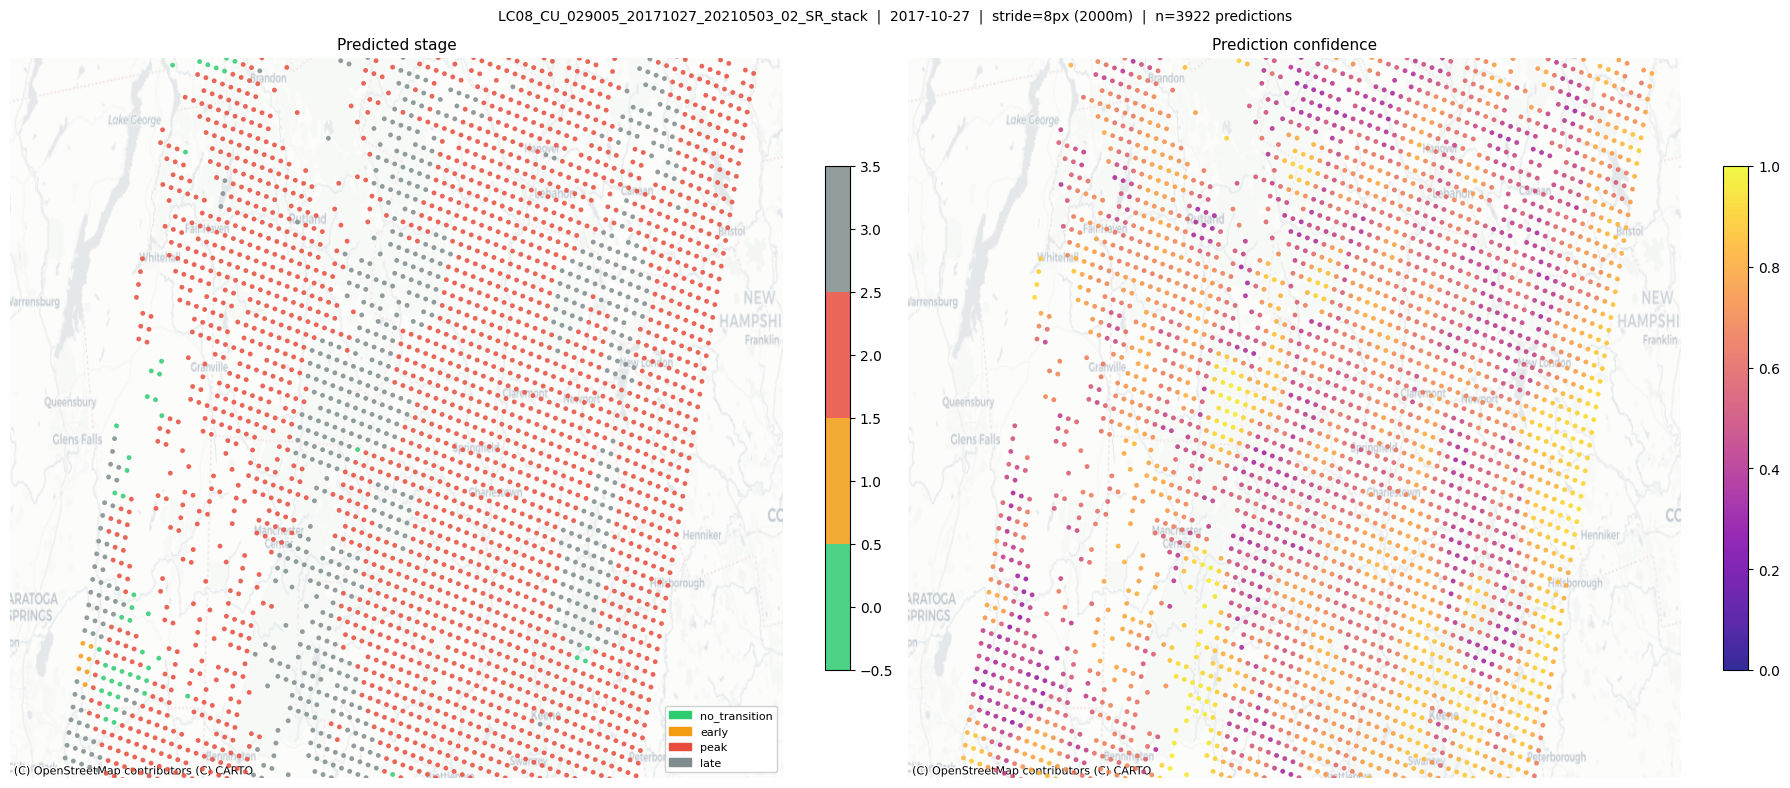

In [90]:
# ── Reconstruct raster and visualise ────────────────────────────────────
try:
    import contextily as ctx
    from pyproj import Transformer as _T
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

# Build a sparse classification raster at the prediction grid resolution
pred_grid = np.full((H, W), -1, dtype=np.int8)   # -1 = no prediction
conf_grid = np.full((H, W), np.nan, dtype=np.float32)

for i, (r, c) in enumerate(zip(grid_r, grid_c)):
    pred_grid[r, c] = all_preds[i]
    conf_grid[r, c] = all_probs[i, all_preds[i]]

# ── Map: predicted class ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_i, (ax, title, data, cmap, vmin, vmax) in enumerate([
    (axes[0], 'Predicted stage', pred_grid, STAGE_CMAP, -0.5, 3.5),
    (axes[1], 'Prediction confidence', conf_grid, 'plasma', 0, 1),
]):
    if HAS_CTX:
        _proj  = _T.from_crs(str(crs), 'EPSG:3857', always_xy=True)
        xmin_m, ymin_m = _proj.transform(bounds.left,  bounds.bottom)
        xmax_m, ymax_m = _proj.transform(bounds.right, bounds.top)

        # Build scatter in Web Mercator
        valid = pred_grid[grid_r, grid_c] >= 0
        xs, ys = _proj.transform(
            [transform.c + c * transform.a for c in grid_c[valid]],
            [transform.f + r * transform.e for r in grid_r[valid]],
        )
        vals = data[grid_r[valid], grid_c[valid]]
        sc   = ax.scatter(xs, ys, c=vals, cmap=cmap, vmin=vmin, vmax=vmax,
                          s=max(1, STRIDE**1.2), alpha=0.85,
                          linewidths=0, zorder=5)
        ax.set_xlim(xmin_m, xmax_m)
        ax.set_ylim(ymin_m, ymax_m)
        try:
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron,
                            zorder=1, alpha=0.6, crs='EPSG:3857')
        except Exception:
            pass
        ax.set_axis_off()
    else:
        ax.imshow(np.ma.masked_where(data < 0, data),
                  cmap=cmap, vmin=vmin, vmax=vmax,
                  interpolation='nearest', origin='upper')

    plt.colorbar(sc if HAS_CTX else ax.images[0], ax=ax, fraction=0.03)
    ax.set_title(title, fontsize=11)

# Stage legend
legend = [mpatches.Patch(color=STAGE_COLORS[i], label=STAGE_NAMES[i])
          for i in range(NUM_CLASSES)]
axes[0].legend(handles=legend, loc='lower right', fontsize=8, framealpha=0.9)

fig.suptitle(
    f'{SCENE_PATH.stem}  |  {scene_date}  |  stride={STRIDE}px ({STRIDE*250}m)  |  '
    f'n={valid_mask.sum()} predictions',
    fontsize=10
)
plt.tight_layout()
plt.show()


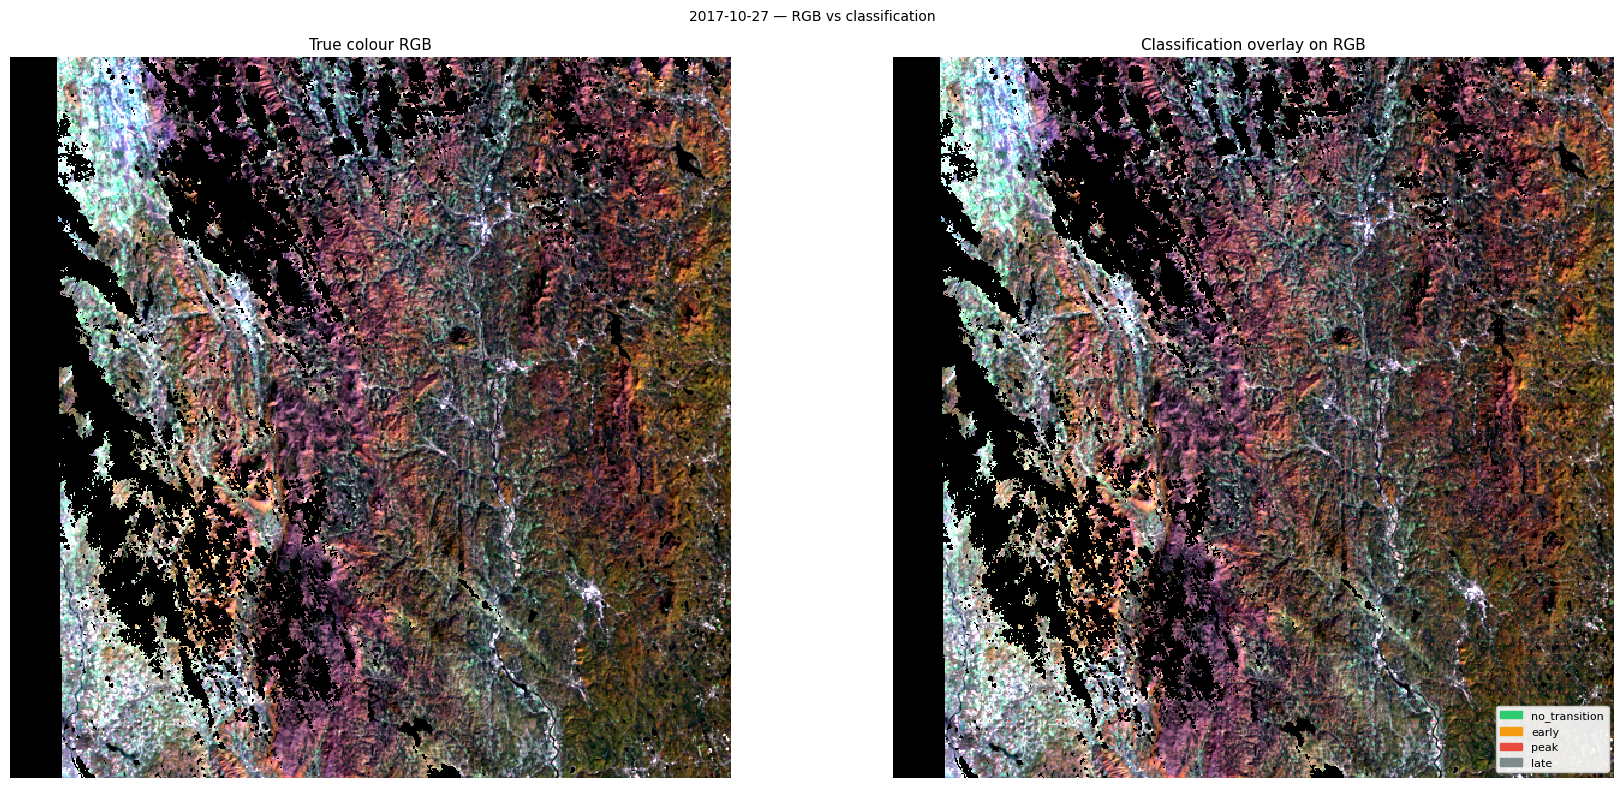

In [91]:
# ── RGB true-colour comparison ───────────────────────────────────────────
# Show the raw Landsat RGB alongside the classification for visual sanity check.
# Red=band2(red), Green=band1(green), Blue=band0(blue)

def percentile_stretch(arr, pct=2):
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0: return np.zeros_like(arr)
    lo, hi = np.percentile(valid, pct), np.percentile(valid, 100-pct)
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)

rgb = np.stack([
    percentile_stretch(spectral[2]),   # red
    percentile_stretch(spectral[1]),   # green
    percentile_stretch(spectral[0]),   # blue
], axis=-1)
rgb = np.nan_to_num(rgb)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(rgb, interpolation='nearest', origin='upper')
axes[0].set_title('True colour RGB', fontsize=11)
axes[0].axis('off')

# Overlay predictions on a white background
pred_rgba = np.ones((H, W, 4), dtype=np.float32)  # white background
for stage_i, hex_col in STAGE_COLORS.items():
    r_col = int(hex_col[1:3], 16) / 255
    g_col = int(hex_col[3:5], 16) / 255
    b_col = int(hex_col[5:7], 16) / 255
    mask  = pred_grid == stage_i
    pred_rgba[mask] = [r_col, g_col, b_col, 0.85]

# Mask out unpredicted pixels (cloud/edge)
pred_rgba[pred_grid < 0, 3] = 0.0

axes[1].imshow(rgb, interpolation='nearest', origin='upper')
axes[1].imshow(pred_rgba, interpolation='nearest', origin='upper')
axes[1].set_title('Classification overlay on RGB', fontsize=11)
axes[1].axis('off')

legend = [mpatches.Patch(color=STAGE_COLORS[i], label=STAGE_NAMES[i])
          for i in range(NUM_CLASSES)]
axes[1].legend(handles=legend, loc='lower right', fontsize=8, framealpha=0.9)

fig.suptitle(f'{scene_date} — RGB vs classification', fontsize=10)
plt.tight_layout()
plt.show()


In [92]:
# ── Scene browser: scroll through multiple scenes ────────────────────────
# Select different dates for the same tile to see how classifications
# evolve through the fall season.

# Find all stacks for the same tile position as SCENE_PATH
tile_id = '_'.join(SCENE_PATH.stem.split('_')[2:3])   # e.g. '030008'
same_tile = sorted(
    p for p in all_stacks if f'_{tile_id}_' in p.stem
)
print(f'Scenes for tile {tile_id}: {len(same_tile)}')
for p in same_tile:
    print(f'  {p.stem}')


Scenes for tile 029005: 72
  LC08_CU_029005_20130820_20210501_02_SR_stack
  LC08_CU_029005_20130930_20210501_02_SR_stack
  LC08_CU_029005_20140901_20210502_02_SR_stack
  LC08_CU_029005_20140908_20210502_02_SR_stack
  LC08_CU_029005_20140917_20210502_02_SR_stack
  LC08_CU_029005_20140924_20210502_02_SR_stack
  LC08_CU_029005_20141003_20210502_02_SR_stack
  LC08_CU_029005_20141111_20210505_02_SR_stack
  LC08_CU_029005_20150803_20210502_02_SR_stack
  LC08_CU_029005_20150819_20210502_02_SR_stack
  LC08_CU_029005_20150904_20210502_02_SR_stack
  LC08_CU_029005_20150927_20210502_02_SR_stack
  LC08_CU_029005_20151006_20210502_02_SR_stack
  LC08_CU_029005_20151123_20210502_02_SR_stack
  LC08_CU_029005_20160805_20210502_02_SR_stack
  LC08_CU_029005_20160828_20210502_02_SR_stack
  LC08_CU_029005_20160913_20210502_02_SR_stack
  LC08_CU_029005_20160922_20210502_02_SR_stack
  LC08_CU_029005_20160929_20210502_02_SR_stack
  LC08_CU_029005_20161024_20210502_02_SR_stack
  LC08_CU_029005_20170824_2021050

## Prediction Consistency
Heuristically, the model should produce coherent regions with predictions that agree with one another. We test for the existence of such regions by examining correlation length - how far away do you need to move before the model's predictions become uncorrelated with where you started?

In [117]:
def correlation_length(grid_r, grid_c, all_preds, transform,
                        max_dist_km=200, n_bins=30, n_pairs=50_000,
                        rng_seed=42):
    """Estimate spatial correlation length of predicted labels.

    Computes the label agreement rate as a function of pairwise distance,
    then fits an exponential decay C(r) = exp(-r / L) to find the
    characteristic length scale L (correlation length).

    Parameters
    ----------
    grid_r, grid_c : arrays of pixel row/col of each prediction
    all_preds      : integer predicted label for each grid point
    transform      : rasterio transform (pixel → CRS coordinates)
    max_dist_km    : maximum distance to consider (km)
    n_bins         : number of distance bins
    n_pairs        : number of random pairs to sample (more = smoother)
    rng_seed       : random seed for reproducibility

    Returns
    -------
    bin_centers_km : array of bin center distances (km)
    agreement      : agreement rate at each distance
    L_km           : fitted correlation length (km), or None if fit fails
    """
    from scipy.optimize import curve_fit

    rng = np.random.default_rng(rng_seed)
    n   = len(grid_r)

    # Convert pixel centers to CRS coordinates (metres in EPSG:5070)
    xs = transform.c + (grid_c + 0.5) * transform.a
    ys = transform.f + (grid_r + 0.5) * transform.e

    # Sample random pairs
    idx_a = rng.integers(0, n, size=n_pairs)
    idx_b = rng.integers(0, n, size=n_pairs)
    # Avoid self-pairs
    same  = idx_a == idx_b
    idx_b[same] = (idx_b[same] + 1) % n

    dx   = xs[idx_a] - xs[idx_b]
    dy   = ys[idx_a] - ys[idx_b]
    dist = np.sqrt(dx**2 + dy**2) / 1000   # km

    agree = (all_preds[idx_a] == all_preds[idx_b]).astype(float)

    # Bin by distance
    bin_edges   = np.linspace(0, max_dist_km, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_agree   = np.full(n_bins, np.nan)
    bin_n       = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        mask = (dist >= bin_edges[i]) & (dist < bin_edges[i+1])
        if mask.sum() > 0:
            bin_agree[i] = agree[mask].mean()
            bin_n[i]     = mask.sum()

    # Baseline agreement (random chance for 4 classes)
    n_classes = len(np.unique(all_preds))
    baseline  = 1.0 / max(n_classes, 1)

    # Fit exponential decay to (agreement - baseline)
    # C(r) = (C0 - baseline) * exp(-r / L) + baseline
    valid = ~np.isnan(bin_agree)
    L_km  = None
    if valid.sum() >= 4:
        try:
            C0_init = bin_agree[valid][0]
            def model(r, C0, L):
                return (C0 - baseline) * np.exp(-r / L) + baseline
            popt, _ = curve_fit(
                model,
                bin_centers[valid],
                bin_agree[valid],
                p0=[C0_init, 50.0],
                bounds=([baseline, 1.0], [1.0, max_dist_km * 2]),
                maxfev=2000,
            )
            L_km = popt[1]
        except Exception as e:
            print(f'  Fit failed: {e}')

    return bin_centers, bin_agree, bin_n, L_km

def seasonal_correlation_analysis(n_scenes_per_month=3, stride=16,
                                   batch_size=512, months=range(8, 12)):
    """Run correlation length analysis across months.

    For each month, samples up to n_scenes_per_month stacks, runs inference,
    computes correlation length, and returns a summary DataFrame.
    """
    from collections import defaultdict

    results_by_month = defaultdict(list)

    for month in months:
        stacks = find_stacks(month=month)
        if not stacks:
            print(f'Month {month}: no stacks found')
            continue

        # Sample without replacement
        rng_sel = np.random.default_rng(42)
        sample  = rng_sel.choice(stacks,
                                  size=min(n_scenes_per_month, len(stacks)),
                                  replace=False).tolist()

        print(f'\nMonth {month}: {len(sample)} scenes')

        for scene_path in sample:
            stem  = scene_path.stem.replace('_stack', '')
            parts = stem.split('_')
            year  = int(parts[3][:4])
            date  = f'{parts[3][:4]}-{parts[3][4:6]}-{parts[3][6:8]}'
            print(f'  {date} ...', end=' ', flush=True)

            try:
                # Load cube
                with rasterio.open(scene_path) as src:
                    spectral  = src.read().astype(np.float32)
                    transform = src.transform
                    H, W      = src.height, src.width

                elevation      = _load_dem(DEM_PATH, transform, (H, W))
                slope, aspect  = _slope_aspect(elevation)
                nlcd           = NLCDLayer(year)
                decid          = nlcd.deciduous_fraction(transform, (H, W))
                cube = np.concatenate([
                    spectral, elevation[np.newaxis], slope[np.newaxis],
                    aspect[np.newaxis], decid[np.newaxis],
                ], axis=0).astype(np.float32)

                # Grid
                half   = PATCH_SIZE // 2
                rows   = np.arange(half, H - half, stride)
                cols   = np.arange(half, W - half, stride)
                gr, gc = np.meshgrid(rows, cols, indexing='ij')
                gr, gc = gr.ravel(), gc.ravel()
                valid  = ~np.isnan(cube[:9, gr, gc]).any(axis=0)
                gr, gc = gr[valid], gc[valid]

                if len(gr) < 100:
                    print('too few valid pixels — skipped')
                    continue

                # Inference
                probs = np.zeros((len(gr), NUM_CLASSES), dtype=np.float32)
                for start in range(0, len(gr), batch_size):
                    br, bc   = gr[start:start+batch_size], gc[start:start+batch_size]
                    patches  = np.stack([cube[:, r-half:r+half, c-half:c+half]
                                         for r, c in zip(br, bc)])
                    for b in range(len(patches)):
                        for ch in range(patches.shape[1]):
                            nm = np.isnan(patches[b, ch])
                            if nm.any():
                                vm = np.nanmean(patches[b, ch])
                                patches[b, ch][nm] = vm if np.isfinite(vm) else 0.0
                    pt = torch.stack([normalizer(torch.from_numpy(p))
                                      for p in patches]).to(DEVICE)
                    with torch.no_grad():
                        probs[start:start+len(br)] = F.softmax(
                            model(pt), dim=1
                        ).cpu().numpy()

                preds = probs.argmax(axis=1)
                bin_centers, agreement, bin_n, L_km = correlation_length(gr, gc, preds, transform)

                print(f'L = {L_km:.1f} km' if L_km else 'fit failed')
                results_by_month[month].append({
                    'date':       date,
                    'n_pred':     len(preds),
                    'L_km':       L_km,
                    'bin_centers': bin_centers,
                    'agreement':   agreement,
                })

            except Exception as e:
                print(f'ERROR: {e}')

    # Summary plot
    month_names = ['', 'Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    month_list  = sorted(results_by_month.keys())
    L_means     = []
    L_stds      = []
    L_all       = []

    for m in month_list:
        ls = [r['L_km'] for r in results_by_month[m] if r['L_km'] is not None]
        L_means.append(np.mean(ls) if ls else np.nan)
        L_stds.append(np.std(ls)   if ls else np.nan)
        L_all.append(ls)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: mean ± std per month
    ax = axes[0]
    xs = np.array(month_list)
    ax.errorbar(xs, L_means, yerr=L_stds, fmt='o-', color='steelblue',
                capsize=4, linewidth=2, markersize=7)
    ax.set_xticks(month_list)
    ax.set_xticklabels([month_names[m] for m in month_list])
    ax.set_ylabel('Correlation length (km)')
    ax.set_title('Spatial coherence through the season')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)

    # Right: individual scene curves for one example month (October)
    # Right: one curve per scene for the example month
    example_month = 10 if 10 in results_by_month else month_list[-1]
    ax2 = axes[1]
    baseline = 1.0 / NUM_CLASSES

    for r in results_by_month[example_month]:
        bc  = r.get('bin_centers')
        agr = r.get('agreement')
        if bc is None or agr is None:
            continue
        valid = ~np.isnan(agr)
        label = r['date'] + (f"  L={r['L_km']:.0f}km" if r['L_km'] else '')
        ax2.plot(bc[valid], agr[valid], alpha=0.7, label=label)
        if r['L_km']:
            # Plot fitted exponential
            C0  = agr[valid][0] if valid.any() else 0.5
            fit = (C0 - baseline) * np.exp(-bc / r['L_km']) + baseline
            ax2.plot(bc, fit, linestyle='--', alpha=0.4)

    ax2.axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Random baseline ({NUM_CLASSES} classes)')
    ax2.set_xlabel('Distance (km)')
    ax2.set_ylabel('Label agreement rate')
    ax2.set_title(f'Correlation curves — {month_names[example_month]}')
    ax2.set_ylim(0, 1)
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3)

    plt.suptitle('Spatial correlation length analysis', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame([
        {'month': month_names[m], 'n_scenes': len(results_by_month[m]),
         'mean_L_km': round(L_means[i], 1) if not np.isnan(L_means[i]) else None,
         'std_L_km':  round(L_stds[i],  1) if not np.isnan(L_stds[i])  else None}
        for i, m in enumerate(month_list)
    ])
    print('\nCorrelation length summary:')
    print(summary.to_string(index=False))
    return summary

In [ ]:
summary = seasonal_correlation_analysis(n_scenes_per_month=10, stride=8)

Found 494 stacks  month=8

Month 8: 10 scenes
  2014-08-07 ... 